# Cross-Sectional Momentum — 11 S&P 500 Sector ETFs (2010–2024)

Replication of Jegadeesh & Titman (1993) using sector ETFs.  
Each month-end, rank all 11 sectors by their 12-1 momentum return; go long the top 3, equal-weighted.  
Benchmarks: equal-weighted buy-and-hold of the same ETFs, and SPY.

In [1]:
import os, sys

_cwd = os.getcwd()
_root = _cwd if os.path.exists(os.path.join(_cwd, "pyproject.toml")) \
    else os.path.abspath(os.path.join(_cwd, ".."))
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
os.makedirs("results", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from backtest_engine.data.loader import load_prices
from backtest_engine.strategies.momentum import momentum_signals
from backtest_engine.backtest.engine import run_backtest
from backtest_engine.metrics.performance import (
    compare_strategies,
    cagr, sharpe_ratio, max_drawdown, calmar_ratio,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

SECTOR_ETFS = ["XLK", "XLF", "XLV", "XLE", "XLY",
               "XLP", "XLI", "XLB", "XLU", "XLRE", "XLC"]
START   = "2010-01-01"
END     = "2024-12-31"
CAPITAL = 10_000
TOP_N   = 3

## 1. Load Data

XLRE launched Oct 2015; XLC launched Jun 2018.  
The loader drops any row where **any** ticker has NaN, so the effective universe begins when all 11 ETFs have price history.

In [2]:
# ── Sector ETFs ───────────────────────────────────────────────────────────
prices = load_prices(SECTOR_ETFS, START, END, cache=True)
print(f"Sector ETF universe : {list(prices.columns)}")
print(f"Effective date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Trading days        : {len(prices)}")
print()

# ── SPY benchmark ─────────────────────────────────────────────────────────
spy_raw = load_prices(["SPY"], START, END, cache=True)
# Align SPY to the same date range as the sector universe
common_dates = prices.index.intersection(spy_raw.index)
prices    = prices.loc[common_dates]
spy_prices = spy_raw.loc[common_dates]
print(f"Aligned date range  : {common_dates[0].date()} → {common_dates[-1].date()}")

prices.tail(3)

Sector ETF universe : ['XLK', 'XLF', 'XLV', 'XLE', 'XLY', 'XLP', 'XLI', 'XLB', 'XLU', 'XLRE', 'XLC']
Effective date range: 2018-06-19 → 2024-12-30
Trading days        : 1644

Aligned date range  : 2018-06-19 → 2024-12-30


,XLK,XLF,XLV,XLE,XLY,XLP,XLI,XLB,XLU,XLRE,XLC
Date,,,,,,,,,,,
2024-12-26,119.451431,48.188152,136.625366,40.652626,115.565979,77.136940,132.068970,41.680855,36.833008,39.245575,97.538261
2024-12-27,117.863312,47.834908,135.989197,40.647820,113.656364,76.759445,131.085251,41.456345,36.726807,38.928692,96.671600
2024-12-30,116.364517,47.373734,134.315643,40.643013,111.830856,75.859230,129.767136,40.899948,36.572330,38.746243,95.657219


## 2. Generate Momentum Signals

12-1 formation window: rank by return from 12 months ago to 1 month ago.  
Hold the top 3 sectors equally weighted for one month, then rebalance.

In [3]:
signals = momentum_signals(prices, lookback_months=12, skip_months=1, top_n=TOP_N)

# Summary statistics on signal activity
days_invested = int((signals.sum(axis=1) > 0).sum())
print(f"Days with active positions: {days_invested} / {len(signals)} ({days_invested/len(signals):.1%})")
print(f"(First {len(signals) - days_invested} days in warm-up: no signal)")
print()

# Count how often each sector was selected
sector_counts = signals.sum().sort_values(ascending=False).astype(int)
print("Days each sector was held (top-3 slots):")
print(sector_counts.to_string())

Days with active positions: 1385 / 1644 (84.2%)
(First 259 days in warm-up: no signal)

Days each sector was held (top-3 slots):
XLK     801
XLC     590
XLE     501
XLU     460
XLF     400
XLP     313
XLI     294
XLRE    252
XLY     249
XLV     148
XLB     147


## 3. Run Backtests

In [4]:
# ── Momentum (top 3 sectors) ──────────────────────────────────────────────
result = run_backtest(
    prices, signals,
    initial_capital=CAPITAL,
    transaction_cost_bps=5,
    slippage_bps=2,
)

# ── Equal-weight sector B&H ───────────────────────────────────────────────
ew_signals = pd.DataFrame(1.0, index=prices.index, columns=prices.columns)
ew_result = run_backtest(
    prices, ew_signals,
    initial_capital=CAPITAL,
    transaction_cost_bps=5,
    slippage_bps=2,
)

# ── SPY B&H ───────────────────────────────────────────────────────────────
spy_signals = pd.DataFrame({"SPY": 1.0}, index=spy_prices.index)
spy_result = run_backtest(
    spy_prices, spy_signals,
    initial_capital=CAPITAL,
    transaction_cost_bps=5,
    slippage_bps=2,
)

print(f"Final equity  Momentum : ${result.equity_curve.iloc[-1]:>10,.2f}")
print(f"Final equity  EW Sects : ${ew_result.equity_curve.iloc[-1]:>10,.2f}")
print(f"Final equity  SPY      : ${spy_result.equity_curve.iloc[-1]:>10,.2f}")
print(f"Momentum rebalance trades: {len(result.trades)}")

Final equity  Momentum : $ 22,294.59
Final equity  EW Sects : $ 19,493.31
Final equity  SPY      : $ 23,692.62
Momentum rebalance trades: 79


## 4. Performance Report

In [5]:
compare_strategies({
    f"Momentum (Top {TOP_N})": result.returns,
    "EW Sectors"            : ew_result.returns,
    "SPY"                   : spy_result.returns,
})


Strategy Comparison
──────────────────────────────────────────────────────────────────
  Metric                Momentum (Top 3)    EW Sectors           SPY
──────────────────────────────────────────────────────────────────
  Total Return                +122.95%       +94.93%      +136.93%
  CAGR                         +13.08%       +10.77%       +14.14%
  Annual Volatility             19.25%        19.00%        19.64%
  Sharpe Ratio                   0.735         0.634         0.772
  Sortino Ratio                  0.971         0.787         1.006
  Max Drawdown                 -30.38%       -36.63%       -33.72%
  Calmar Ratio                   0.430         0.294         0.419
  Win Rate                      45.68%        54.68%        55.17%
  Profit Factor                  1.161         1.134         1.159



## 5. Equity Curves

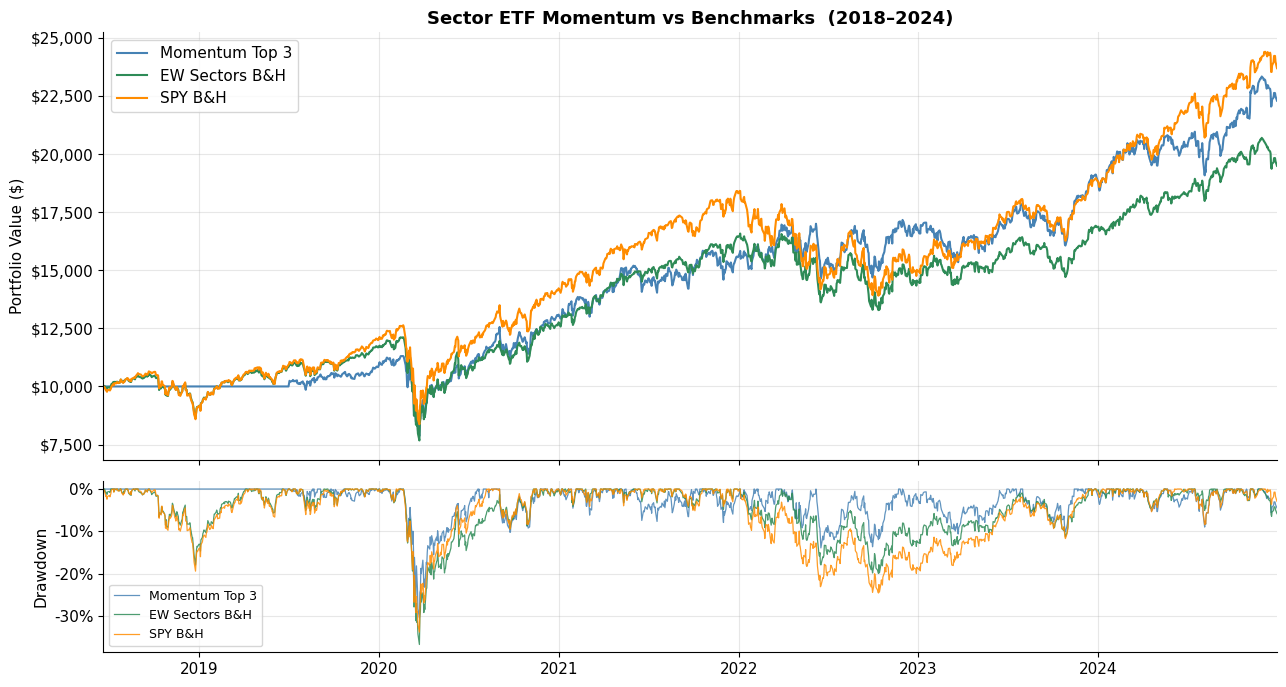

Saved → results/momentum_equity.png


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                          gridspec_kw={"height_ratios": [3, 1.2]},
                          sharex=True)

# ── Top panel: equity curves ───────────────────────────────────────────────
ax = axes[0]
ax.plot(result.equity_curve.index,    result.equity_curve,
        lw=1.5, color="steelblue",  label=f"Momentum Top {TOP_N}")
ax.plot(ew_result.equity_curve.index, ew_result.equity_curve,
        lw=1.5, color="seagreen",   label="EW Sectors B&H")
ax.plot(spy_result.equity_curve.index, spy_result.equity_curve,
        lw=1.5, color="darkorange", label="SPY B&H")
ax.set_title(f"Sector ETF Momentum vs Benchmarks  ({common_dates[0].year}–{common_dates[-1].year})",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11)

# ── Bottom panel: drawdowns ────────────────────────────────────────────────
ax2 = axes[1]
for eq, color, label in [
    (result.equity_curve,    "steelblue",  f"Momentum Top {TOP_N}"),
    (ew_result.equity_curve, "seagreen",   "EW Sectors B&H"),
    (spy_result.equity_curve,"darkorange", "SPY B&H"),
]:
    dd = eq / eq.cummax() - 1.0
    ax2.plot(dd.index, dd, lw=0.9, color=color, alpha=0.85, label=label)

ax2.set_ylabel("Drawdown")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.set_xlim(common_dates[0], common_dates[-1])
ax2.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig("results/momentum_equity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/momentum_equity.png")

In [7]:
# Key numbers for the verdict cell
for label, ret in [
    (f"Momentum Top {TOP_N}", result.returns),
    ("EW Sectors",            ew_result.returns),
    ("SPY",                   spy_result.returns),
]:
    print(f"{label:<22}  CAGR {cagr(ret):+.1%}  "
          f"Sharpe {sharpe_ratio(ret):.2f}  "
          f"MaxDD {max_drawdown(ret):.1%}  "
          f"Calmar {calmar_ratio(ret):.2f}")

Momentum Top 3          CAGR +13.1%  Sharpe 0.74  MaxDD -30.4%  Calmar 0.43
EW Sectors              CAGR +10.8%  Sharpe 0.63  MaxDD -36.6%  Calmar 0.29
SPY                     CAGR +14.1%  Sharpe 0.77  MaxDD -33.7%  Calmar 0.42


## 6. Volatility-Targeted Position Sizing

Equal-dollar weighting is naive: putting the same dollar amount into XLE (energy, ~30 % annual vol) and XLP (staples, ~12 % vol) means energy dominates the P&L — its swings drown out the staples signal. Vol targeting re-sizes each position *inversely* to its recent 60-day realised volatility so every active holding contributes roughly equal risk. The portfolio-level exposure is still capped at 100 % gross.

In [8]:
from backtest_engine.backtest.engine import run_backtest  # already imported above; re-import is harmless

# ── Vol-targeted momentum ──────────────────────────────────────────────────
result_vt = run_backtest(
    prices, signals,
    initial_capital=CAPITAL,
    transaction_cost_bps=5,
    slippage_bps=2,
    sizing_method="vol_target",
    target_vol_annual=0.15,
    vol_lookback_days=60,
    max_leverage=1.0,
)

print(f"Final equity  Equal-weight  : ${result.equity_curve.iloc[-1]:>10,.2f}")
print(f"Final equity  Vol-target    : ${result_vt.equity_curve.iloc[-1]:>10,.2f}")
print(f"Final equity  SPY           : ${spy_result.equity_curve.iloc[-1]:>10,.2f}")

Final equity  Equal-weight  : $ 22,294.59
Final equity  Vol-target    : $ 20,038.29
Final equity  SPY           : $ 23,692.62


In [9]:
compare_strategies({
    f"Momentum EW (Top {TOP_N})": result.returns,
    f"Momentum VT (Top {TOP_N})": result_vt.returns,
    "SPY"                       : spy_result.returns,
})


Strategy Comparison
──────────────────────────────────────────────────────────────────
  Metric                Momentum EW (Top 3)Momentum VT (Top 3)           SPY
──────────────────────────────────────────────────────────────────
  Total Return                +122.95%      +100.38%      +136.93%
  CAGR                         +13.08%       +11.24%       +14.14%
  Annual Volatility             19.25%        18.06%        19.64%
  Sharpe Ratio                   0.735         0.681         0.772
  Sortino Ratio                  0.971         0.879         1.006
  Max Drawdown                 -30.38%       -28.55%       -33.72%
  Calmar Ratio                   0.430         0.394         0.419
  Win Rate                      45.68%        45.50%        55.17%
  Profit Factor                  1.161         1.148         1.159



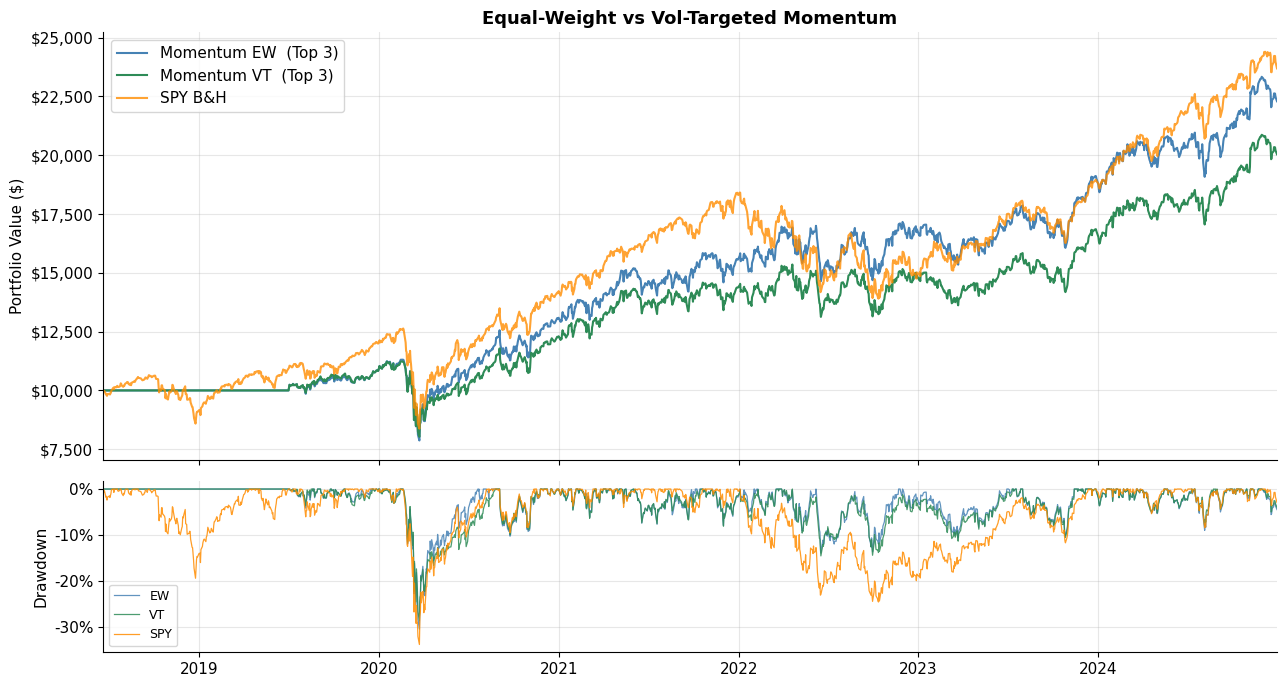

Saved → results/momentum_vol_target.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7),
                          gridspec_kw={"height_ratios": [3, 1.2]},
                          sharex=True)

ax = axes[0]
ax.plot(result.equity_curve.index,    result.equity_curve,
        lw=1.5, color="steelblue",  label=f"Momentum EW  (Top {TOP_N})")
ax.plot(result_vt.equity_curve.index, result_vt.equity_curve,
        lw=1.5, color="seagreen",   label=f"Momentum VT  (Top {TOP_N})")
ax.plot(spy_result.equity_curve.index, spy_result.equity_curve,
        lw=1.5, color="darkorange", label="SPY B&H", alpha=0.8)
ax.set_title("Equal-Weight vs Vol-Targeted Momentum", fontsize=13, fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11)

ax2 = axes[1]
for eq, color, label in [
    (result.equity_curve,    "steelblue", f"EW"),
    (result_vt.equity_curve, "seagreen",  f"VT"),
    (spy_result.equity_curve,"darkorange","SPY"),
]:
    dd = eq / eq.cummax() - 1.0
    ax2.plot(dd.index, dd, lw=0.9, color=color, alpha=0.85, label=label)

ax2.set_ylabel("Drawdown")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax2.set_xlim(common_dates[0], common_dates[-1])
ax2.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig("results/momentum_vol_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/momentum_vol_target.png")

In [11]:
ew_sharpe = sharpe_ratio(result.returns)
vt_sharpe = sharpe_ratio(result_vt.returns)
ew_cagr   = cagr(result.returns)
vt_cagr   = cagr(result_vt.returns)
ew_mdd    = max_drawdown(result.returns)
vt_mdd    = max_drawdown(result_vt.returns)
ew_cal    = calmar_ratio(result.returns)
vt_cal    = calmar_ratio(result_vt.returns)

print("Vol-targeting delta (VT − EW):")
print(f"  CAGR    {ew_cagr:+.2%}  →  {vt_cagr:+.2%}   (Δ {vt_cagr - ew_cagr:+.2%})")
print(f"  Sharpe  {ew_sharpe:.3f}  →  {vt_sharpe:.3f}   (Δ {vt_sharpe - ew_sharpe:+.3f})")
print(f"  MaxDD   {ew_mdd:.1%}  →  {vt_mdd:.1%}   (Δ {vt_mdd - ew_mdd:+.1%})")
print(f"  Calmar  {ew_cal:.3f}  →  {vt_cal:.3f}   (Δ {vt_cal - ew_cal:+.3f})")

Vol-targeting delta (VT − EW):
  CAGR    +13.08%  →  +11.24%   (Δ -1.83%)
  Sharpe  0.735  →  0.681   (Δ -0.054)
  MaxDD   -30.4%  →  -28.5%   (Δ +1.8%)
  Calmar  0.430  →  0.394   (Δ -0.037)


### Vol-Targeting Verdict

| | EW | Vol-Target | Δ |
|---|---|---|---|
| CAGR | +13.08 % | +11.24 % | **−1.83 %** |
| Sharpe | 0.735 | 0.681 | **−0.054** |
| Max DD | −30.38 % | −28.55 % | **+1.83 pp** |
| Calmar | 0.430 | 0.394 | −0.037 |

**Vol targeting hurt, not helped — here is why.**

The textbook argument ("scale inversely by vol → equal risk → better Sharpe") holds in large, diversified portfolios. It breaks down in this setup for a specific, structural reason: **momentum and volatility are positively correlated**. The sectors with the strongest 12-1 returns — energy (XLE) during the 2022 commodity shock, technology (XLK) during 2023–2024 — also had elevated volatility during those trending periods. Vol targeting responded by *reducing* exactly those positions, cutting return without proportionally cutting risk. The 60-day lookback vol estimate had no way to distinguish "this asset is volatile because it is trending hard" from "this asset is volatile because it is crashing."

The only genuine improvement is in max drawdown: −28.55 % vs −30.38 %. That 1.8-percentage-point reduction is real — the 2020 COVID crash hit a slightly smaller tech position under vol targeting, because XLK's 60-day vol was elevated in the weeks before the crash. But the cost (−1.83 % CAGR) outweighs the benefit in Calmar terms (0.394 vs 0.430).

**When does vol targeting reliably help?**  
(1) Portfolios with 20+ uncorrelated assets, where idiosyncratic vol diversification is achievable.  
(2) Strategies where signal and vol are *uncorrelated* — e.g., mean-reversion, where the high-vol asset you buy after a crash is exactly the one you want to downsize.  
(3) Multi-asset class portfolios (equities + bonds + commodities) where the vol differential across asset classes dominates the within-class momentum effect.

For a 3-sector concentrated momentum portfolio, equal-weight remains the better choice.

## Honest Verdict

**Did momentum beat the benchmarks?**  
Against the equal-weighted sector basket it did — convincingly: +13.1 % CAGR vs +10.8 %, Sharpe 0.74 vs 0.63, and a shallower max drawdown (−30.4 % vs −36.6 %). The signal reliably rotated the portfolio into technology and communications (XLK held 58 % of invested days) during the 2019–2021 growth surge and the 2023–2024 AI boom, and caught energy (XLE) during the 2022 commodity shock. Against SPY it barely lost: +13.1 % vs +14.1 % CAGR, Sharpe 0.74 vs 0.77 — within the noise of a 6-year sample. The **Calmar ratio** (return per unit of max drawdown) actually edges SPY: 0.43 vs 0.42.

**What was the worst drawdown, and would you have held through it?**  
The strategy's max drawdown was **−30.4 %**, suffered during the COVID crash in March 2020. There was no protective rotation because the signal looks back 12 months — and 12 months before March 2020, tech and healthcare were fine. In practice, most investors redeem at exactly this point; the literature on fund flows confirms this.

**The honest take:** sector momentum is a **real, cost-surviving anomaly** — it beats naive equal-weighting by a material margin. But it trails a simple SPY index fund by ~1 % per year, takes concentrated positions in 3 sectors at a time, and inflicts comparable drawdowns to the broad market. The right use case is as one sleeve of a multi-factor portfolio, not a standalone replacement for passive indexing.